# 솔루션 1)  사고 유형별·연령별 교통사고 현황 분석

본 장에서는 분석대상지의 교통사고, 교통량, 유동인구 데이터를 활용하여  
사고 유형별·연령별 교통사고 현황을 분석하고,  
사고 발생 원인과 지역적 특성을 도출하고자 한다.

- 첫 번째 해결 내용에 있는 문제를 데이터로 해결하고자 한다.
`분석대상지의 교통사고, 교통량, 유동인구 데이터를 활용하여 사고 유형별·연령별 교통사고 현황을 분석하고, 사고 발생 원인과 지역적 특성을 도출합니다.`

주요 분석 목표는 다음과 같다.

1. 전체 교통사고의 연령별 분포와 사고 유형을 파악한다.  
2. 취약계층(어린이, 노인)의 사고 특성을 비교한다.  
3. 사고 발생 시간, 위반 유형, 도로 유형 등 사고 맥락을 확인한다.  
4. 교통량 및 유동인구와 사고 발생의 관계를 살펴본다.  

In [1]:
# 필요한 라이브러리 불러오기
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

In [2]:
# 필요한 데이터셋 불러오기
DATA_DIR = Path("../dataset")
OUT_DIR  = Path("../outputs/processed")
OUT_DIR.mkdir(exist_ok=True)

IMG_DIR = OUT_DIR / "images" / "03_accident_profile_analysis"
IMG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
mpl.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (9, 5)

print("DATA_DIR:", DATA_DIR)
print("OUT_DIR :", OUT_DIR)
print("IMG_DIR :", IMG_DIR)

DATA_DIR: ../dataset
OUT_DIR : ../outputs/processed
IMG_DIR : ../outputs/processed/images/03_accident_profile_analysis


## 1 데이터 불러오기

먼저 분석에 사용할 교통사고, 교통량, 유동인구, 격자 데이터를 불러온다.  
파일명은 데이터셋 폴더 내 실제 존재 여부를 확인하여 자동으로 선택하도록 구성하였다.

In [3]:
def pick_existing_file(base_dir, candidates):
    for name in candidates:
        fp = base_dir / name
        if fp.exists():
            return fp
    raise FileNotFoundError(f"다음 파일들 중 존재하는 파일을 찾을 수 없습니다: {candidates}")

acc_fp = pick_existing_file(DATA_DIR, [
    "13._교통사고이력.geojson"
])

traffic_fp = pick_existing_file(DATA_DIR, [
    "10._추정교통량.csv"
])

flow_fp = pick_existing_file(DATA_DIR, [
    "04._성연령별_유동인구_전처리.csv",
    "04._성연령별_유동인구.csv",
    "56._시간대별_유동인구.csv"
])

grid_fp = pick_existing_file(DATA_DIR, [
    "01_grid_4city_fix.geojson",
    "01._격자_(4개_시·구).geojson"
])

print("사고 데이터 파일   :", acc_fp.name)
print("교통량 데이터 파일 :", traffic_fp.name)
print("유동인구 데이터 파일:", flow_fp.name)
print("격자 데이터 파일   :", grid_fp.name)

사고 데이터 파일   : 13._교통사고이력.geojson
교통량 데이터 파일 : 10._추정교통량.csv
유동인구 데이터 파일: 04._성연령별_유동인구.csv
격자 데이터 파일   : 01._격자_(4개_시·구).geojson


In [4]:
acc = gpd.read_file(acc_fp)
traffic = pd.read_csv(traffic_fp)
flow = pd.read_csv(flow_fp)
grid = gpd.read_file(grid_fp)

print("acc shape     :", acc.shape)
print("traffic shape :", traffic.shape)
print("flow shape    :", flow.shape)
print("grid shape    :", grid.shape)

display(acc.head(2))
display(traffic.head(2))
display(flow.head(2))
display(grid.head(2))

acc shape     : (10821, 19)
traffic shape : (926518, 14)
flow shape    : (3416198, 16)
grid shape    : (99323, 4)


,acc_yr,acc_mon,week_type,acc_time,sgg,acc_type,violation,road_type,road_sttus,weather,attckr_vhcle,victim_vhcle,injury_svrity,age_group,dprs_cnt,sep_cnt,slp_cnt,inj_aplcnt_cnt,geometry
0,2024,1,주중,19시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,기타 - 기타,건조,맑음,승용,이륜,경상,41-50세,0,0,1,0,POINT (127.13635 37.37966)
1,2024,1,주중,07시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,기타 - 기타,건조,맑음,승용,이륜,부상신고,41-50세,0,0,0,1,POINT (127.12005 37.34924)


,v_link_id,road_rank,k_length,sido_id,sigungu_id,emd_id,sido_name,sigungu_name,emd_name,timeslot,ALL_AADT,PSCR_AADT,BUS_AADT,FGCR_AADT
0,57166862101,104,1.32,11000,11240,11240820,서울특별시,송파구,위례동,0,331,236,5,89
1,57166862102,104,1.32,11000,11240,11240820,서울특별시,송파구,위례동,0,564,457,5,103


,gbn,STD_YM,m_10g_pop,m_20g_pop,m_30g_pop,m_40g_pop,m_50g_pop,m_60g_pop,w_10g_pop,w_20g_pop,w_30g_pop,w_40g_pop,w_50g_pop,w_60g_pop,lon,lat
0,경기도 성남시,202401,0.0,0.01,0.01,0.03,0.04,0.08,0.01,0.01,0.01,0.01,0.03,0.04,127.027716,37.372890
1,경기도 성남시,202401,0.0,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.01,127.028241,37.379202


,std_yr,gbn,gid,geometry
0,2024,경기도 성남시,다사581304,"POLYGON ((127.02677 37.37172, 127.02677 37.372..."
1,2024,경기도 성남시,다사581305,"POLYGON ((127.02677 37.37262, 127.02676 37.373..."


In [5]:
# 데이터들의 컬럼들을 다 확인하기

print("사고 데이터 컬럼 ")
print(acc.columns.tolist())

print("\n\n 교통량 데이터 컬럼 ")
print(traffic.columns.tolist())

print("\n\n 유동인구 데이터 컬럼 ")
print(flow.columns.tolist())

print("\n\n 격자 데이터 컬럼")
print(grid.columns.tolist())

사고 데이터 컬럼 
['acc_yr', 'acc_mon', 'week_type', 'acc_time', 'sgg', 'acc_type', 'violation', 'road_type', 'road_sttus', 'weather', 'attckr_vhcle', 'victim_vhcle', 'injury_svrity', 'age_group', 'dprs_cnt', 'sep_cnt', 'slp_cnt', 'inj_aplcnt_cnt', 'geometry']


 교통량 데이터 컬럼 
['v_link_id', 'road_rank', 'k_length', 'sido_id', 'sigungu_id', 'emd_id', 'sido_name', 'sigungu_name', 'emd_name', 'timeslot', 'ALL_AADT', 'PSCR_AADT', 'BUS_AADT', 'FGCR_AADT']


 유동인구 데이터 컬럼 
['gbn', 'STD_YM', 'm_10g_pop', 'm_20g_pop', 'm_30g_pop', 'm_40g_pop', 'm_50g_pop', 'm_60g_pop', 'w_10g_pop', 'w_20g_pop', 'w_30g_pop', 'w_40g_pop', 'w_50g_pop', 'w_60g_pop', 'lon', 'lat']


 격자 데이터 컬럼
['std_yr', 'gbn', 'gid', 'geometry']


## 2 사고 데이터 전처리

사고 데이터에서 분석에 필요한 주요 컬럼만 선택하고,  
사고 시각(`acc_time`)으로부터 사고 발생 시간(`hour`) 및 시간대 구간(`time_band`)을 생성한다.

또한 취약계층 분석을 위해 어린이(12세 이하)와 노인(65세 이상) 여부를 구분하는 변수를 생성한다.

In [6]:
acc = acc.copy()

expected_cols = [
    "acc_yr", "acc_mon", "week_type", "acc_time", "sgg", "acc_type",
    "violation", "road_type", "road_sttus", "weather",
    "attckr_vhcle", "victim_vhcle", "injury_svrity", "age_group",
    "dprs_cnt", "sep_cnt", "slp_cnt", "inj_aplcnt_cnt", "geometry"
]

use_cols = [c for c in expected_cols if c in acc.columns]
acc = acc[use_cols].copy()

acc = acc.reset_index(drop=True).reset_index().rename(columns={"index": "acc_id"})

acc["acc_time"] = acc["acc_time"].astype(str).str.zfill(4)
acc["hour"] = acc["acc_time"].str[:2].astype(int)

def make_time_band(h):
    if 7 <= h <= 9:
        return "07-09"
    elif 10 <= h <= 15:
        return "10-15"
    elif 16 <= h <= 19:
        return "16-19"
    elif 20 <= h <= 23:
        return "20-23"
    else:
        return "00-06"

acc["time_band"] = acc["hour"].apply(make_time_band)

acc["is_child"] = (acc["age_group"] == "12세 이하").astype(int)
acc["is_elderly"] = (acc["age_group"] == "65세 이상").astype(int)

print(acc.shape)
display(acc.head())

(10821, 24)


,acc_id,acc_yr,acc_mon,week_type,acc_time,sgg,acc_type,violation,road_type,road_sttus,...,age_group,dprs_cnt,sep_cnt,slp_cnt,inj_aplcnt_cnt,geometry,hour,time_band,is_child,is_elderly
0,0,2024,1,주중,019시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,기타 - 기타,건조,...,41-50세,0,0,1,0,POINT (127.13635 37.37966),1,00-06,0,0
1,1,2024,1,주중,007시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,기타 - 기타,건조,...,41-50세,0,0,0,1,POINT (127.12005 37.34924),0,00-06,0,0
2,2,2024,1,주중,010시,경기도 성남시 분당구,차대차 - 기타,안전거리미확보,교차로 - 교차로부근,건조,...,51-60세,0,1,0,0,POINT (127.13826 37.40957),1,00-06,0,0
3,3,2024,1,주중,017시,경기도 성남시 분당구,차대차 - 충돌,안전거리미확보,기타 - 기타,건조,...,31-40세,0,1,0,0,POINT (127.10030 37.39987),1,00-06,0,0
4,4,2024,1,주중,023시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,교차로 - 교차로부근,건조,...,31-40세,0,0,1,0,POINT (127.10431 37.40320),2,00-06,0,0


## 3 전체 교통사고 현황

먼저 전체 교통사고의 규모와 함께  
어린이 및 노인 사고의 비중을 확인한다.

In [7]:
basic_summary = pd.DataFrame({
    "지표": [
        "전체 사고 건수",
        "어린이 사고 건수",
        "노인 사고 건수",
        "어린이 사고 비율",
        "노인 사고 비율"
    ],
    "값": [
        len(acc),
        acc["is_child"].sum(),
        acc["is_elderly"].sum(),
        round(acc["is_child"].mean(), 4),
        round(acc["is_elderly"].mean(), 4),
    ]
})

display(basic_summary)

,지표,값
0,전체 사고 건수,10821.0000
1,어린이 사고 건수,212.0000
2,노인 사고 건수,1303.0000
3,어린이 사고 비율,0.0196
4,노인 사고 비율,0.1204


### 3.1 연령별 사고 분포

연령대별 사고 건수를 확인하여  
어떤 연령대에서 사고가 많이 발생하는지 살펴본다.

In [8]:
age_counts = acc["age_group"].fillna("Unknown").value_counts().reset_index()
age_counts.columns = ["age_group", "count"]
display(age_counts)

,age_group,count
0,41-50세,2234
1,31-40세,2186
2,51-60세,1947
3,21-30세,1442
4,65세 이상,1303
5,61-64세,724
6,Unknown,421
7,13-20세,333
8,12세 이하,212
9,기타불명,19


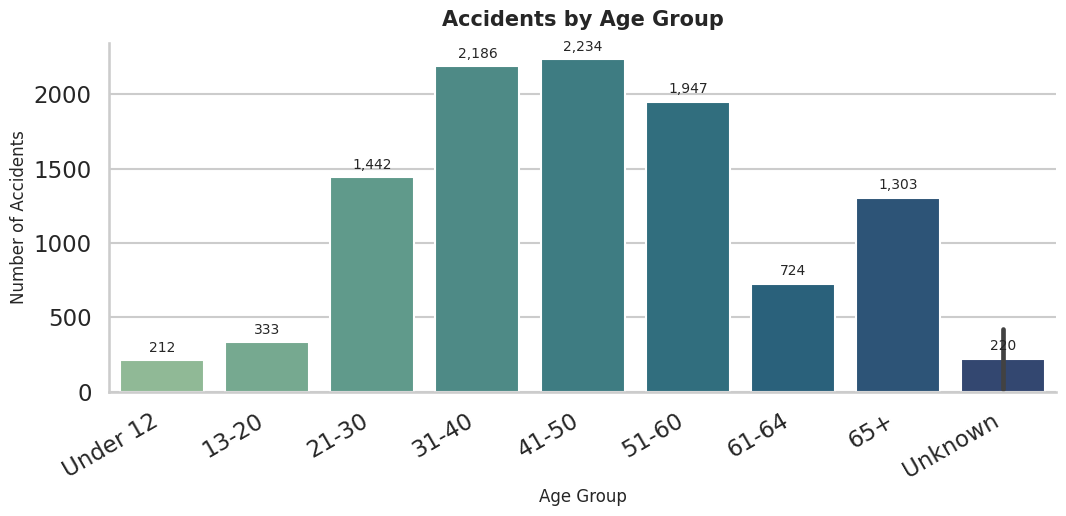

In [36]:
# age_group 영문 라벨 매핑
age_map = {
    "12세 이하": "Under 12",
    "13-20세": "13-20",
    "21-30세": "21-30",
    "31-40세": "31-40",
    "41-50세": "41-50",
    "51-60세": "51-60",
    "61-64세": "61-64",
    "65세 이상": "65+",
    "기타불명": "Unknown",
    "Unknown": "Unknown"
}

age_counts_plot = age_counts.copy()
age_counts_plot["age_group_en"] = age_counts_plot["age_group"].map(age_map).fillna(age_counts_plot["age_group"])

age_order = [
    "Under 12", "13-20", "21-30", "31-40", "41-50",
    "51-60", "61-64", "65+", "Unknown"
]
age_counts_plot["age_group_en"] = pd.Categorical(
    age_counts_plot["age_group_en"],
    categories=age_order,
    ordered=True
)
age_counts_plot = age_counts_plot.sort_values("age_group_en")

# 스타일 설정
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(11, 5.5))
ax = sns.barplot(
    data=age_counts_plot,
    x="age_group_en",
    y="count",
    palette="crest"
)

# 막대 위 값 표시
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height):
        ax.annotate(
            f"{int(height):,}",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 4),
            textcoords="offset points"
        )

plt.title("Accidents by Age Group", fontsize=15, weight="bold", pad=12)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Number of Accidents", fontsize=12)
plt.xticks(rotation=30, ha="right")
sns.despine()
plt.tight_layout()

# 파일 저장
plt.savefig(IMG_DIR / "01_accidents_by_age_group.png", dpi=200, bbox_inches="tight")
plt.show()

### 3.2 사고 유형 분포

전체 사고에서 어떤 사고 유형이 많이 발생하는지 확인한다.

In [10]:
acc_type_counts = acc["acc_type"].fillna("Unknown").value_counts().reset_index()
acc_type_counts.columns = ["acc_type", "count"]
display(acc_type_counts)

,acc_type,count
0,차대차 - 기타,3678
1,차대차 - 충돌,3140
2,차대차 - 추돌,1707
3,차대사람 - 기타,970
4,차대사람 - 횡단중,549
5,차량단독 - 기타,291
6,차대사람 - 보도통행중,166
7,차대사람 - 차도통행중,132
8,차량단독 - 충돌,97
9,차대사람 - 길가장자리구역통행중,58


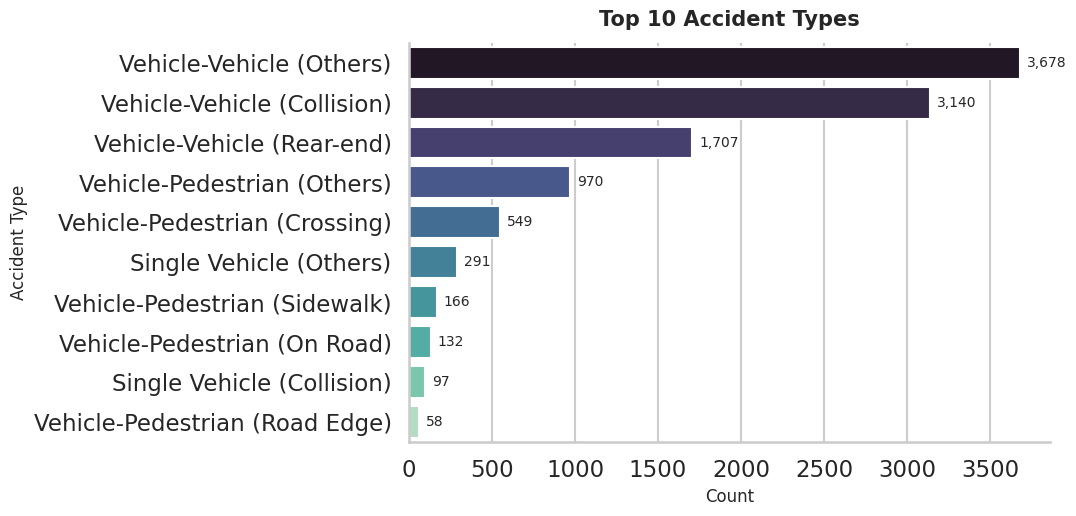

In [39]:
plot_df = acc_type_counts.head(10).copy()

def translate_acc_type(x):
    parts = x.split(" - ")
    
    main_map = {
        "차대차": "Vehicle-Vehicle",
        "차대사람": "Vehicle-Pedestrian",
        "차량단독": "Single Vehicle"
    }
    
    sub_map = {
        "기타": "Others",
        "충돌": "Collision",
        "추돌": "Rear-end",
        "횡단중": "Crossing",
        "보도통행중": "Sidewalk",
        "차도통행중": "On Road",
        "길가장자리구역통행중": "Road Edge",
        "전도전복": "Rollover",
        "도로외이탈": "Road Departure",
        "추락": "Fall"
    }
    
    if len(parts) == 2:
        main = main_map.get(parts[0], parts[0])
        sub = sub_map.get(parts[1], parts[1])
        return f"{main} ({sub})"
    
    elif len(parts) == 3:
        main = main_map.get(parts[0], parts[0])
        sub1 = sub_map.get(parts[1], parts[1])
        sub2 = sub_map.get(parts[2], parts[2])
        return f"{main} ({sub1}-{sub2})"
    
    else:
        return x

plot_df["acc_type_en"] = plot_df["acc_type"].apply(translate_acc_type)

sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(11, 5.5))
ax = sns.barplot(
    data=plot_df,
    x="count",
    y="acc_type_en",
    palette="mako"
)

for p in ax.patches:
    width = p.get_width()
    if pd.notnull(width):
        ax.annotate(
            f"{int(width):,}",
            (width, p.get_y() + p.get_height() / 2),
            ha="left",
            va="center",
            fontsize=10,
            xytext=(5, 0),
            textcoords="offset points"
        )

plt.title("Top 10 Accident Types", fontsize=15, weight="bold", pad=12)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Accident Type", fontsize=12)

sns.despine()
plt.tight_layout()

plt.savefig(IMG_DIR / "02_top10_accident_types.png", dpi=200, bbox_inches="tight")
plt.show()

In [38]:
acc_type_counts["acc_type"].unique()

array(['차대차 - 기타', '차대차 - 충돌', '차대차 - 추돌', '차대사람 - 기타', '차대사람 - 횡단중',
       '차량단독 - 기타', '차대사람 - 보도통행중', '차대사람 - 차도통행중', '차량단독 - 충돌',
       '차대사람 - 길가장자리구역통행중', '차량단독 - 전도전복', '차량단독 - 도로외이탈 - 기타',
       '차량단독 - 도로외이탈 - 추락'], dtype=object)

## 4 취약계층 사고 비교 분석

취약계층인 어린이와 노인 사고를 별도로 분리한 뒤,  
사고 유형, 위반 유형, 도로 유형, 시간대 분포를 비교하여  
각 집단의 사고 특성을 파악한다.

In [12]:
child_acc = acc[acc["age_group"] == "12세 이하"].copy()
elderly_acc = acc[acc["age_group"] == "65세 이상"].copy()

print("어린이 사고 수:", len(child_acc))
print("노인 사고 수  :", len(elderly_acc))

어린이 사고 수: 212
노인 사고 수  : 1303


### 4.1 사고 유형 비교

어린이와 노인 사고가 어떤 사고 유형에서 주로 발생하는지 비교한다.

In [13]:
child_type = child_acc["acc_type"].value_counts(normalize=True)
elderly_type = elderly_acc["acc_type"].value_counts(normalize=True)

compare_type = pd.concat([child_type, elderly_type], axis=1).fillna(0)
compare_type.columns = ["child_ratio", "elderly_ratio"]
compare_type = compare_type.sort_values("child_ratio", ascending=False)

display(compare_type.head(10))

,child_ratio,elderly_ratio
acc_type,,
차대사람 - 횡단중,0.316038,0.090560
차대사람 - 기타,0.292453,0.190330
차대차 - 기타,0.132075,0.280123
차대사람 - 보도통행중,0.122642,0.017652
차대차 - 충돌,0.089623,0.241750
차대사람 - 차도통행중,0.018868,0.027629
차대차 - 추돌,0.018868,0.142748
차대사람 - 길가장자리구역통행중,0.009434,0.009210


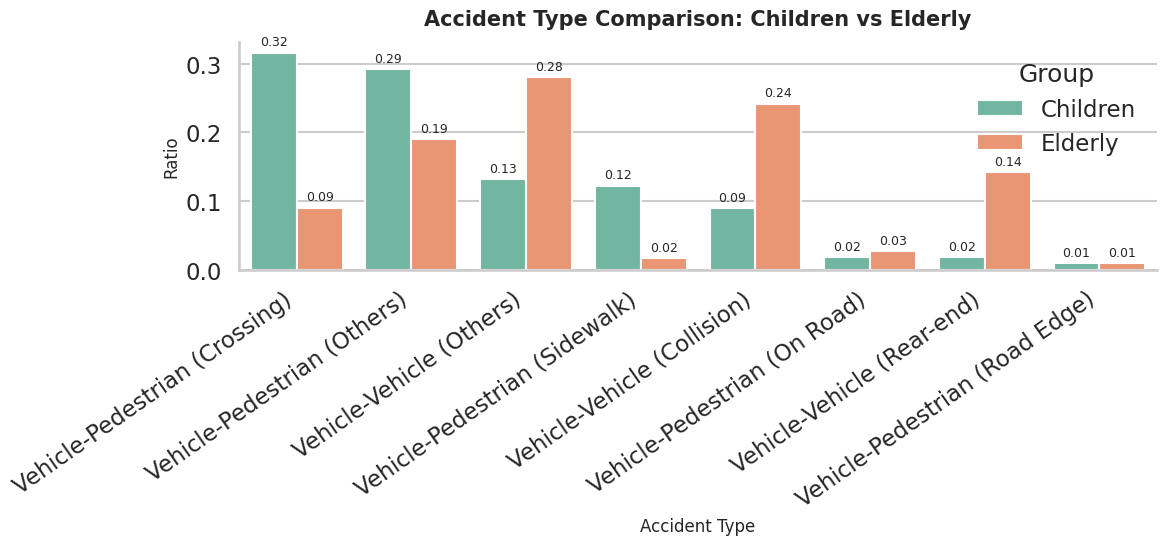

In [40]:
plot_type = compare_type.head(8).reset_index().rename(columns={"index": "acc_type"})

def translate_acc_type(x):
    parts = x.split(" - ")
    
    main_map = {
        "차대차": "Vehicle-Vehicle",
        "차대사람": "Vehicle-Pedestrian",
        "차량단독": "Single Vehicle"
    }
    
    sub_map = {
        "기타": "Others",
        "충돌": "Collision",
        "추돌": "Rear-end",
        "횡단중": "Crossing",
        "보도통행중": "Sidewalk",
        "차도통행중": "On Road",
        "길가장자리구역통행중": "Road Edge",
        "전도전복": "Rollover",
        "도로외이탈": "Road Departure",
        "추락": "Fall"
    }
    
    if len(parts) == 2:
        main = main_map.get(parts[0], parts[0])
        sub = sub_map.get(parts[1], parts[1])
        return f"{main} ({sub})"
    elif len(parts) == 3:
        main = main_map.get(parts[0], parts[0])
        sub1 = sub_map.get(parts[1], parts[1])
        sub2 = sub_map.get(parts[2], parts[2])
        return f"{main} ({sub1}-{sub2})"
    else:
        return x

plot_type["acc_type_en"] = plot_type["acc_type"].apply(translate_acc_type)

plot_type_melt = plot_type.melt(
    id_vars="acc_type_en",
    value_vars=["child_ratio", "elderly_ratio"],
    var_name="group",
    value_name="ratio"
)

group_map = {
    "child_ratio": "Children",
    "elderly_ratio": "Elderly"
}
plot_type_melt["group_en"] = plot_type_melt["group"].map(group_map)

sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(12, 5.8))
ax = sns.barplot(
    data=plot_type_melt,
    x="acc_type_en",
    y="ratio",
    hue="group_en",
    palette="Set2"
)

for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        ax.annotate(
            f"{height:.2f}",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points"
        )

plt.xticks(rotation=35, ha="right")
plt.title("Accident Type Comparison: Children vs Elderly", fontsize=15, weight="bold", pad=12)
plt.xlabel("Accident Type", fontsize=12)
plt.ylabel("Ratio", fontsize=12)
plt.legend(title="Group", frameon=False)
sns.despine()
plt.tight_layout()

plt.savefig(IMG_DIR / "03_child_vs_elderly_acc_type.png", dpi=200, bbox_inches="tight")
plt.show()

### 4.2 위반 유형 비교

사고 발생 시 주요 위반 유형을 비교하여  
운전자 또는 교통행태 측면의 차이를 확인한다.

In [15]:
child_violation = child_acc["violation"].value_counts(normalize=True)
elderly_violation = elderly_acc["violation"].value_counts(normalize=True)

compare_violation = pd.concat([child_violation, elderly_violation], axis=1).fillna(0)
compare_violation.columns = ["child_ratio", "elderly_ratio"]

display(compare_violation.head(10))

,child_ratio,elderly_ratio
violation,,
안전운전불이행,0.566038,0.595549
신호위반,0.165094,0.112049
보행자보호의무위반,0.146226,0.047583
기타,0.094340,0.068304
교차로운행방법위반,0.023585,0.041443
중앙선침범,0.004717,0.020721
안전거리미확보,0.000000,0.114351


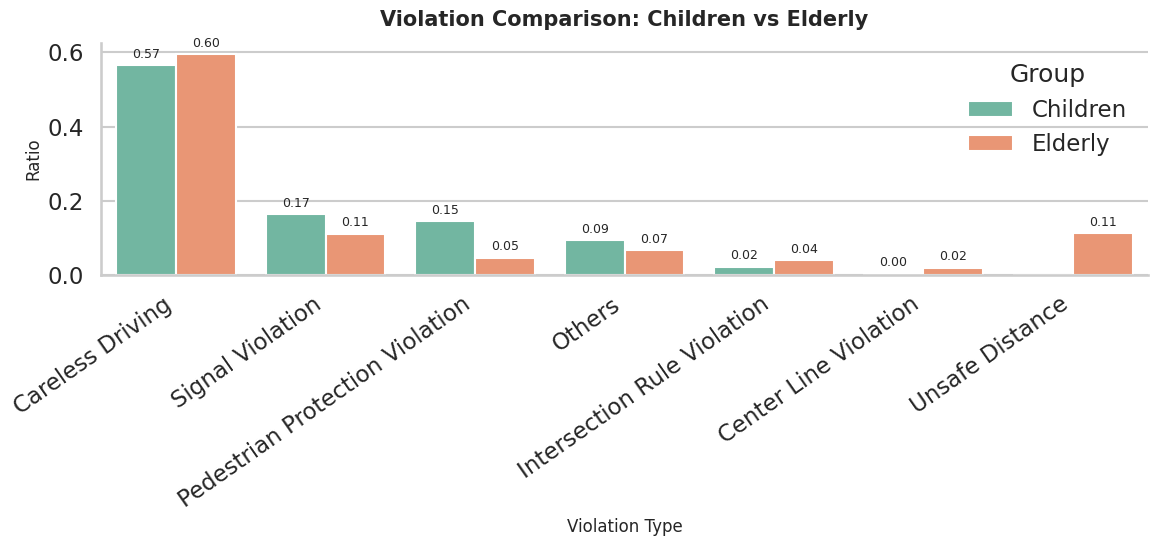

In [41]:
plot_violation = compare_violation.head(8).reset_index().rename(columns={"index": "violation"})

def translate_violation(x):
    violation_map = {
        "안전운전불이행": "Careless Driving",
        "신호위반": "Signal Violation",
        "보행자보호의무위반": "Pedestrian Protection Violation",
        "교차로운행방법위반": "Intersection Rule Violation",
        "안전거리미확보": "Unsafe Distance",
        "중앙선침범": "Center Line Violation",
        "기타": "Others"
    }
    return violation_map.get(x, x)

plot_violation["violation_en"] = plot_violation["violation"].apply(translate_violation)

plot_violation_melt = plot_violation.melt(
    id_vars="violation_en",
    value_vars=["child_ratio", "elderly_ratio"],
    var_name="group",
    value_name="ratio"
)

group_map = {
    "child_ratio": "Children",
    "elderly_ratio": "Elderly"
}
plot_violation_melt["group_en"] = plot_violation_melt["group"].map(group_map)

sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(12, 5.8))
ax = sns.barplot(
    data=plot_violation_melt,
    x="violation_en",
    y="ratio",
    hue="group_en",
    palette="Set2"
)

for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        ax.annotate(
            f"{height:.2f}",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points"
        )

plt.xticks(rotation=35, ha="right")
plt.title("Violation Comparison: Children vs Elderly", fontsize=15, weight="bold", pad=12)
plt.xlabel("Violation Type", fontsize=12)
plt.ylabel("Ratio", fontsize=12)
plt.legend(title="Group", frameon=False)

sns.despine()
plt.tight_layout()

plt.savefig(IMG_DIR / "04_child_vs_elderly_violation.png", dpi=200, bbox_inches="tight")
plt.show()

### 4.3 도로 유형 비교

사고가 어떤 도로 환경에서 주로 발생하는지 확인하기 위해  
도로 유형 분포를 비교한다.

In [17]:
child_road = child_acc["road_type"].value_counts(normalize=True)
elderly_road = elderly_acc["road_type"].value_counts(normalize=True)

compare_road = pd.concat([child_road, elderly_road], axis=1).fillna(0)
compare_road.columns = ["child_ratio", "elderly_ratio"]

display(compare_road.head(10))

,child_ratio,elderly_ratio
road_type,,
단일로 - 기타,0.287736,0.383730
교차로 - 교차로횡단보도내,0.250000,0.061397
기타 - 기타,0.202830,0.161167
교차로 - 교차로안,0.160377,0.209517
교차로 - 교차로부근,0.080189,0.166539
주차장 - 주차장,0.014151,0.001535
단일로 - 지하차도(도로)내,0.004717,0.004605
단일로 - 터널,0.000000,0.005372
단일로 - 교량,0.000000,0.003837


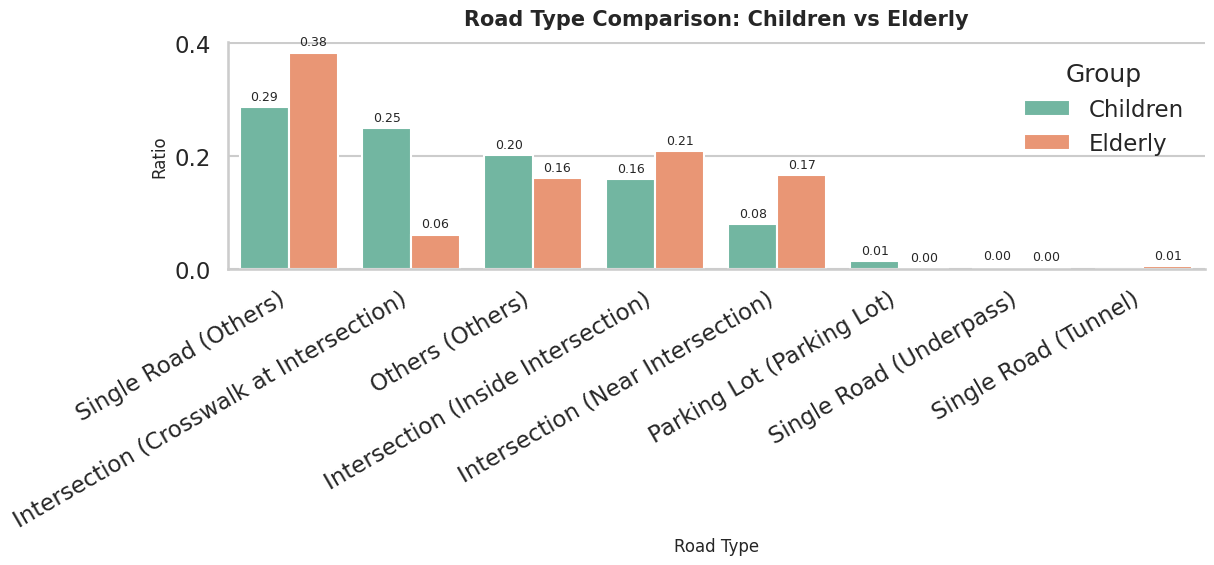

In [44]:
plot_road = compare_road.head(8).reset_index().rename(columns={"index": "road_type"})

def translate_road_type(x):
    parts = x.split(" - ")

    main_map = {
        "교차로": "Intersection",
        "단일로": "Single Road",
        "기타": "Others",
        "주차장": "Parking Lot",
        "미분류": "Unclassified"
    }

    sub_map = {
        "교차로안": "Inside Intersection",
        "교차로부근": "Near Intersection",
        "교차로횡단보도내": "Crosswalk at Intersection",
        "기타": "Others",
        "지하차도(도로)내": "Underpass",
        "터널": "Tunnel",
        "교량": "Bridge",
        "주차장": "Parking Lot",
        "미분류": "Unclassified"
    }

    if len(parts) == 2:
        main = main_map.get(parts[0], parts[0])
        sub = sub_map.get(parts[1], parts[1])
        return f"{main} ({sub})"
    else:
        return x

plot_road["road_type_en"] = plot_road["road_type"].apply(translate_road_type)

plot_road_melt = plot_road.melt(
    id_vars="road_type_en",
    value_vars=["child_ratio", "elderly_ratio"],
    var_name="group",
    value_name="ratio"
)

group_map = {
    "child_ratio": "Children",
    "elderly_ratio": "Elderly"
}
plot_road_melt["group_en"] = plot_road_melt["group"].map(group_map)

sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(12.5, 6))
ax = sns.barplot(
    data=plot_road_melt,
    x="road_type_en",
    y="ratio",
    hue="group_en",
    palette="Set2"
)

for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        ax.annotate(
            f"{height:.2f}",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points"
        )

plt.xticks(rotation=30, ha="right")
plt.title("Road Type Comparison: Children vs Elderly", fontsize=15, weight="bold", pad=12)
plt.xlabel("Road Type", fontsize=12)
plt.ylabel("Ratio", fontsize=12)
plt.legend(title="Group", frameon=False)

sns.despine()
plt.tight_layout()

plt.savefig(IMG_DIR / "05_child_vs_elderly_road_type.png", dpi=200, bbox_inches="tight")
plt.show()

In [43]:
print(compare_road.index.tolist())

['단일로 - 기타', '교차로 - 교차로횡단보도내', '기타 - 기타', '교차로 - 교차로안', '교차로 - 교차로부근', '주차장 - 주차장', '단일로 - 지하차도(도로)내', '단일로 - 터널', '단일로 - 교량', '미분류 - 미분류']


### 4.4 시간대 비교

사고 발생 시간대를 비교하여  
어린이와 노인 사고가 언제 집중되는지 확인한다.

In [19]:
child_time = child_acc["time_band"].value_counts(normalize=True).sort_index()
elderly_time = elderly_acc["time_band"].value_counts(normalize=True).sort_index()

compare_time = pd.concat([child_time, elderly_time], axis=1).fillna(0)
compare_time.columns = ["child_ratio", "elderly_ratio"]

display(compare_time)

,child_ratio,elderly_ratio
time_band,,
00-06,1.0,1.0


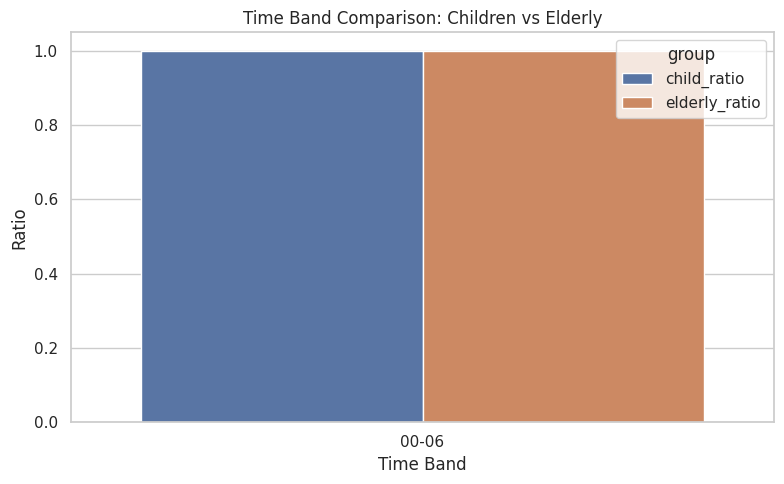

In [20]:
plot_time = compare_time.reset_index().rename(columns={"index": "time_band"})
plot_time_melt = plot_time.melt(
    id_vars="time_band",
    value_vars=["child_ratio", "elderly_ratio"],
    var_name="group",
    value_name="ratio"
)

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_time_melt, x="time_band", y="ratio", hue="group")
plt.title("Time Band Comparison: Children vs Elderly")
plt.xlabel("Time Band")
plt.ylabel("Ratio")
plt.tight_layout()
plt.savefig(IMG_DIR / "06_child_vs_elderly_time_band.png", dpi=200, bbox_inches="tight")
plt.show()

### 4.5 날씨 분포 비교

날씨 조건에 따라 취약계층 사고가 어떻게 분포하는지 확인한다.

In [21]:
child_weather = child_acc["weather"].value_counts(normalize=True)
elderly_weather = elderly_acc["weather"].value_counts(normalize=True)

compare_weather = pd.concat([child_weather, elderly_weather], axis=1).fillna(0)
compare_weather.columns = ["child_ratio", "elderly_ratio"]

display(compare_weather)

,child_ratio,elderly_ratio
weather,,
맑음,0.966981,0.906370
비,0.018868,0.043745
눈,0.009434,0.008442
기타,0.004717,0.013047
흐림,0.000000,0.028396


## 5 교통량 및 유동인구와 사고 발생의 관계

다음으로 사고를 4개 시·구 격자에 매핑한 후,  
사고가 발생한 격자와 그렇지 않은 격자 사이의 교통량 및 유동인구 차이를 살펴본다.

이를 통해 사고가 단순한 우연이 아니라  
교통 및 이동 특성과 관련된 지역적 특성을 가지는지 확인하고자 한다.

In [22]:
acc_gdf = acc.copy()
acc_gdf = gpd.GeoDataFrame(acc_gdf, geometry="geometry", crs=acc.crs)

grid = grid.to_crs(acc_gdf.crs)

print("acc_gdf crs:", acc_gdf.crs)
print("grid crs   :", grid.crs)

acc_gdf crs: EPSG:4326
grid crs   : EPSG:4326


In [23]:
acc_gdf = acc_gdf.drop(columns=[c for c in ["index_left", "index_right"] if c in acc_gdf.columns], errors="ignore")
grid = grid.drop(columns=[c for c in ["index_left", "index_right"] if c in grid.columns], errors="ignore")

acc_grid = gpd.sjoin(
    acc_gdf,
    grid,
    how="inner",
    predicate="within"
)

print("매핑 후 행 수:", len(acc_grid))
print("고유 사고 수:", acc_grid["acc_id"].nunique())

acc_grid = (
    acc_grid
    .sort_values("acc_id")
    .drop_duplicates(subset="acc_id")
    .copy()
)

print("중복 제거 후 행 수:", len(acc_grid))
print("중복 제거 후 고유 사고 수:", acc_grid["acc_id"].nunique())

display(acc_grid.head())

매핑 후 행 수: 10934
고유 사고 수: 10820
중복 제거 후 행 수: 10820
중복 제거 후 고유 사고 수: 10820


,acc_id,acc_yr,acc_mon,week_type,acc_time,sgg,acc_type,violation,road_type,road_sttus,...,inj_aplcnt_cnt,geometry,hour,time_band,is_child,is_elderly,index_right,std_yr,gbn,gid
0,0,2024,1,주중,019시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,기타 - 기타,건조,...,0,POINT (127.13635 37.37966),1,00-06,0,0,9661,2024,경기도 성남시,다사678312
1,1,2024,1,주중,007시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,기타 - 기타,건조,...,1,POINT (127.12005 37.34924),0,00-06,0,0,7458,2024,경기도 성남시,다사663278
2,2,2024,1,주중,010시,경기도 성남시 분당구,차대차 - 기타,안전거리미확보,교차로 - 교차로부근,건조,...,0,POINT (127.13826 37.40957),1,00-06,0,0,9825,2024,경기도 성남시,다사679345
3,3,2024,1,주중,017시,경기도 성남시 분당구,차대차 - 충돌,안전거리미확보,기타 - 기타,건조,...,0,POINT (127.10030 37.39987),1,00-06,0,0,5129,2024,경기도 성남시,다사646334
4,4,2024,1,주중,023시,경기도 성남시 분당구,차대차 - 기타,안전운전불이행,교차로 - 교차로부근,건조,...,0,POINT (127.10431 37.40320),2,00-06,0,0,5536,2024,경기도 성남시,다사649338


In [24]:
candidate_gid_cols = [c for c in grid.columns if c.lower() in ["gid", "grid_id"]]
print("격자 ID 후보 컬럼:", candidate_gid_cols)

GRID_ID_COL = candidate_gid_cols[0] if len(candidate_gid_cols) > 0 else grid.columns[0]
print("사용할 격자 ID 컬럼:", GRID_ID_COL)

격자 ID 후보 컬럼: ['gid']
사용할 격자 ID 컬럼: gid


In [28]:
feature_fp = pick_existing_file(DATA_DIR.parent / "outputs" / "processed", [
    "02_train_base_final_features_v2.csv",
    "02_train_base_final_features.csv",
    "02_train_base_with_facilities.csv",
    "02_train_base_core_features.csv"
])

grid_feature = pd.read_csv(feature_fp)

print("feature file:", feature_fp.name)
print("grid_feature shape:", grid_feature.shape)
print(grid_feature.columns.tolist())

display(grid_feature.head())

feature file: 02_train_base_final_features_v2.csv
grid_feature shape: (105032, 28)
['gid', 'city', 'geometry', 'acc_cnt', 'acc_binary', 'resident_pop', 'flow_pop', 'working_pop', 'visit_pop', 'service_pop', 'mean_speed', 'traffic_volume', 'congestion_freq', 'congestion_time', 'crosswalk_count', 'bus_stop_count', 'school_count', 'kinder_count', 'daycare_count', 'cctv_count', 'speedbump_count', 'is_residential', 'is_commercial', 'is_green', 'is_road', 'is_public', 'blockType_main', 'landuse_group']


,gid,city,geometry,acc_cnt,acc_binary,resident_pop,flow_pop,working_pop,visit_pop,service_pop,...,daycare_count,cctv_count,speedbump_count,is_residential,is_commercial,is_green,is_road,is_public,blockType_main,landuse_group
0,다사581304,경기도 성남시,POLYGON ((127.02677465735422 37.37172194466841...,0,0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0,0,0,0,0,unknown,other
1,다사581305,경기도 성남시,POLYGON ((127.02676899519032 37.37262330005522...,0,0,0.0,0.031594,0.015572,0.016022,0.0,...,0.0,0.0,0.0,0,0,0,0,0,unknown,other
2,다사581306,경기도 성남시,POLYGON ((127.02676333277432 37.37352465530359...,0,0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0,0,0,0,0,unknown,other
3,다사582304,경기도 성남시,POLYGON ((127.02790403835982 37.37172645813172...,0,0,0.0,0.022768,0.018269,0.004499,0.0,...,0.0,0.0,0.0,0,0,0,0,0,unknown,other
4,다사582305,경기도 성남시,POLYGON ((127.02789838970781 37.37262781366482...,0,0,0.0,0.031655,0.016485,0.015169,0.0,...,0.0,0.0,0.0,0,0,0,0,0,unknown,other


In [29]:
required_feature_candidates = [
    "gid", "traffic_volume", "flow_pop", "working_pop", "visit_pop", "service_pop",
    "mean_speed", "congestion_freq", "congestion_time",
    "crosswalk_count", "bus_stop_count", "cctv_count", "speedbump_count"
]

existing_feature_cols = [c for c in required_feature_candidates if c in grid_feature.columns]
print("usable feature columns:", existing_feature_cols)

usable feature columns: ['gid', 'traffic_volume', 'flow_pop', 'working_pop', 'visit_pop', 'service_pop', 'mean_speed', 'congestion_freq', 'congestion_time', 'crosswalk_count', 'bus_stop_count', 'cctv_count', 'speedbump_count']


In [31]:
grid_feat = grid[[GRID_ID_COL, "geometry"]].copy()

merge_cols = [c for c in existing_feature_cols if c != "geometry"]
grid_feat = grid_feat.merge(
    grid_feature[merge_cols].drop_duplicates(subset="gid"),
    on="gid",
    how="left"
)

print(grid_feat.shape)
display(grid_feat.head())

(99323, 14)


,gid,geometry,traffic_volume,flow_pop,working_pop,visit_pop,service_pop,mean_speed,congestion_freq,congestion_time,crosswalk_count,bus_stop_count,cctv_count,speedbump_count
0,다사581304,"POLYGON ((127.02677 37.37172, 127.02677 37.372...",0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,다사581305,"POLYGON ((127.02677 37.37262, 127.02676 37.373...",0.0,0.031594,0.015572,0.016022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,다사581306,"POLYGON ((127.02676 37.37352, 127.02676 37.374...",0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,다사582304,"POLYGON ((127.02790 37.37173, 127.02790 37.372...",0.0,0.022768,0.018269,0.004499,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,다사582305,"POLYGON ((127.02790 37.37263, 127.02789 37.373...",0.0,0.031655,0.016485,0.015169,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
acc_count_by_grid = (
    acc_grid.groupby(GRID_ID_COL)
    .size()
    .reset_index(name="acc_cnt")
)

child_count_by_grid = (
    acc_grid[acc_grid["age_group"] == "12세 이하"]
    .groupby(GRID_ID_COL)
    .size()
    .reset_index(name="child_acc_cnt")
)

elderly_count_by_grid = (
    acc_grid[acc_grid["age_group"] == "65세 이상"]
    .groupby(GRID_ID_COL)
    .size()
    .reset_index(name="elderly_acc_cnt")
)

grid_feat = grid_feat.merge(acc_count_by_grid, on=GRID_ID_COL, how="left")
grid_feat = grid_feat.merge(child_count_by_grid, on=GRID_ID_COL, how="left")
grid_feat = grid_feat.merge(elderly_count_by_grid, on=GRID_ID_COL, how="left")

for c in ["acc_cnt", "child_acc_cnt", "elderly_acc_cnt"]:
    grid_feat[c] = grid_feat[c].fillna(0)

grid_feat["acc_binary"] = (grid_feat["acc_cnt"] > 0).astype(int)
grid_feat["child_binary"] = (grid_feat["child_acc_cnt"] > 0).astype(int)
grid_feat["elderly_binary"] = (grid_feat["elderly_acc_cnt"] > 0).astype(int)

display(grid_feat.head())

,gid,geometry,traffic_volume,flow_pop,working_pop,visit_pop,service_pop,mean_speed,congestion_freq,congestion_time,crosswalk_count,bus_stop_count,cctv_count,speedbump_count,acc_cnt,child_acc_cnt,elderly_acc_cnt,acc_binary,child_binary,elderly_binary
0,다사581304,"POLYGON ((127.02677 37.37172, 127.02677 37.372...",0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
1,다사581305,"POLYGON ((127.02677 37.37262, 127.02676 37.373...",0.0,0.031594,0.015572,0.016022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
2,다사581306,"POLYGON ((127.02676 37.37352, 127.02676 37.374...",0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
3,다사582304,"POLYGON ((127.02790 37.37173, 127.02790 37.372...",0.0,0.022768,0.018269,0.004499,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
4,다사582305,"POLYGON ((127.02790 37.37263, 127.02789 37.373...",0.0,0.031655,0.016485,0.015169,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0


In [33]:
compare_cols = [c for c in [
    "traffic_volume", "flow_pop", "working_pop", "visit_pop", "service_pop",
    "mean_speed", "congestion_freq", "congestion_time",
    "crosswalk_count", "bus_stop_count", "cctv_count", "speedbump_count"
] if c in grid_feat.columns]

rows = []

for label, target_col in [
    ("전체 사고", "acc_binary"),
    ("어린이 사고", "child_binary"),
    ("노인 사고", "elderly_binary")
]:
    for feat in compare_cols:
        rows.append({
            "group": label,
            "feature": feat,
            "mean_when_1": grid_feat.loc[grid_feat[target_col] == 1, feat].mean(),
            "mean_when_0": grid_feat.loc[grid_feat[target_col] == 0, feat].mean(),
            "ratio_1_to_0": (
                grid_feat.loc[grid_feat[target_col] == 1, feat].mean() /
                grid_feat.loc[grid_feat[target_col] == 0, feat].mean()
                if grid_feat.loc[grid_feat[target_col] == 0, feat].mean() not in [0, np.nan]
                else np.nan
            )
        })

numeric_compare = pd.DataFrame(rows)
display(numeric_compare)

,group,feature,mean_when_1,mean_when_0,ratio_1_to_0
0,전체 사고,traffic_volume,656.388533,108.223030,6.065146
1,전체 사고,flow_pop,13.922021,1.053962,13.209220
2,전체 사고,working_pop,3.970150,0.362529,10.951258
3,전체 사고,visit_pop,9.951871,0.691433,14.393104
4,전체 사고,service_pop,1.159453,0.086330,13.430483
5,전체 사고,mean_speed,34.337459,9.717169,3.533690
6,전체 사고,congestion_freq,52.918829,11.381540,4.649531
7,전체 사고,congestion_time,65.811188,14.260566,4.614907
8,전체 사고,crosswalk_count,0.789446,0.056049,14.084910
9,전체 사고,bus_stop_count,0.415398,0.043402,9.570830


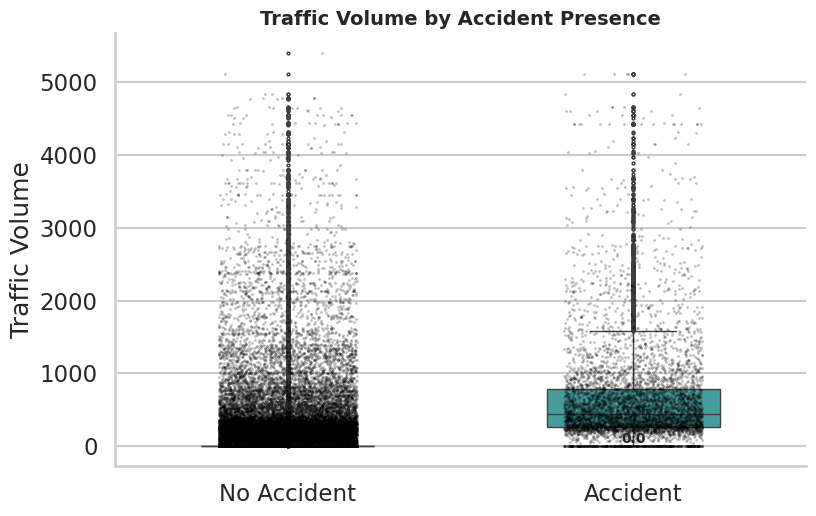

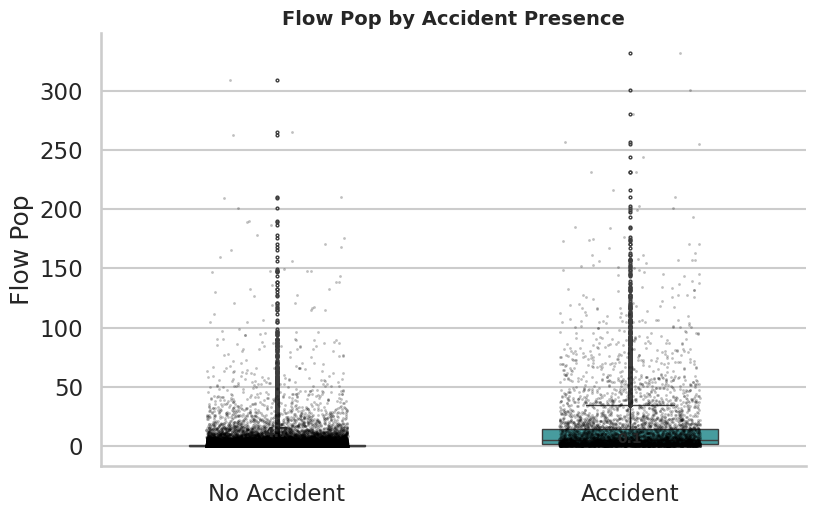

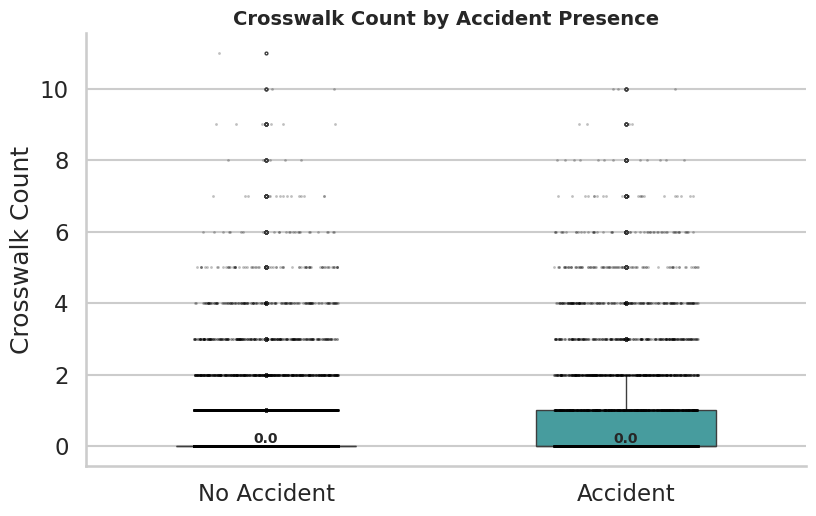

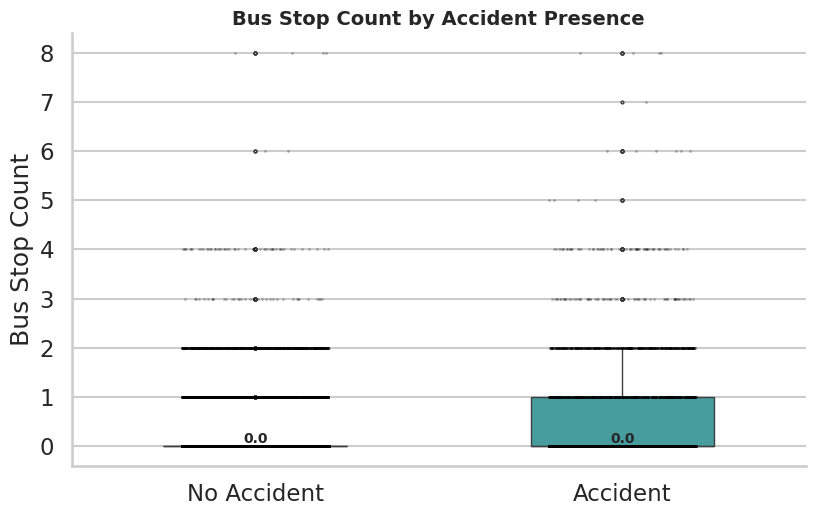

In [45]:
sns.set_theme(style="whitegrid", context="talk")

plot_features = [c for c in ["traffic_volume", "flow_pop", "crosswalk_count", "bus_stop_count"] if c in grid_feat.columns]

for feat in plot_features:
    df_plot = grid_feat.copy()
    
    # 라벨 변환
    df_plot["acc_label"] = df_plot["acc_binary"].map({0: "No Accident", 1: "Accident"})
    
    plt.figure(figsize=(8.5, 5.5))
    
    ax = sns.boxplot(
        data=df_plot,
        x="acc_label",
        y=feat,
        palette="mako",
        width=0.5,
        fliersize=2
    )
    
    sns.stripplot(
        data=df_plot,
        x="acc_label",
        y=feat,
        color="black",
        alpha=0.25,
        size=2,
        jitter=0.2
    )
    
    # 중앙값 표시
    medians = df_plot.groupby("acc_label")[feat].median()
    for i, label in enumerate(medians.index):
        ax.text(
            i,
            medians[label],
            f"{medians[label]:.1f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )
    
    plt.title(f"{feat.replace('_', ' ').title()} by Accident Presence", fontsize=14, weight="bold")
    plt.xlabel("")
    plt.ylabel(feat.replace("_", " ").title())
    
    sns.despine()
    plt.tight_layout()
    
    plt.savefig(IMG_DIR / f"{feat}_by_accident_presence.png", dpi=200, bbox_inches="tight")
    plt.show()

In [35]:
vul_compare = []

for feat in compare_cols:
    vul_compare.append({
        "feature": feat,
        "child_mean": grid_feat.loc[grid_feat["child_binary"] == 1, feat].mean(),
        "elderly_mean": grid_feat.loc[grid_feat["elderly_binary"] == 1, feat].mean(),
        "non_acc_mean": grid_feat.loc[grid_feat["acc_binary"] == 0, feat].mean()
    })

vul_compare = pd.DataFrame(vul_compare)
display(vul_compare)

,feature,child_mean,elderly_mean,non_acc_mean
0,traffic_volume,339.943968,646.362443,108.223030
1,flow_pop,15.672696,20.975740,1.053962
2,working_pop,3.895197,5.695580,0.362529
3,visit_pop,11.777499,15.280160,0.691433
4,service_pop,1.305081,1.747368,0.086330
5,mean_speed,23.442810,31.927591,9.717169
6,congestion_freq,57.981225,52.428693,11.381540
7,congestion_time,71.857616,65.599989,14.260566
8,crosswalk_count,1.495238,0.991158,0.056049
9,bus_stop_count,0.495238,0.503095,0.043402


어린이 및 노인 사고가 발생한 격자는 비사고 격자에 비해 교통량, 유동인구, 혼잡도, 보행시설 밀도가 전반적으로 높게 나타났다. 
- 특히 어린이 사고는 횡단보도 밀집 생활권과, 
- 노인 사고는 유동인구와 교통량이 큰 생활 이동 축과 더 밀접한 관련을 보인다.

# 취약계층 분석 


1. 전체 사고 현황
- 전체 사고 10,821건 중 노인 사고(1,303건)가 어린이 사고(212건)보다 약 6배 많음  
- 사고는 주로 30~50대에서 많이 발생하나,  
  취약계층(어린이·노인)도 일정 비율 존재  
- 전체 사고는 대부분 차량 간 사고(차대차)가 중심

2. 어린이 vs 노인 사고 유형 차이 
- 어린이 사고는 ‘차대사람 - 횡단중’ 비율이 가장 높음  
→ 보행 중 사고 중심

- 노인 사고는 ‘차대차’ 비율이 높음  
→ 차량 간 충돌 및 교통 흐름 영향 큼

- 즉,
  어린이 = 보행자 중심 사고  
  노인 = 차량 중심 사고
  
3. 위반 유형 차이
- 두 집단 모두 ‘안전운전불이행’이 가장 큰 원인

- 어린이:
  → 보행자 보호 의무 위반 비율 높음

- 노인:
  → 신호위반, 안전거리 미확보 등 운전 행태 문제 비중 증가

- 즉,
  어린이 사고 = 보행자 보호 문제  
  노인 사고 = 운전 행태 문제
  
4. 도로 유형 차이 
- 어린이:
  → 교차로 횡단보도 구간 비율 높음

- 노인:
  → 단일로 + 교차로 전반적으로 분산

- 즉,
  어린이 = “횡단 환경 중심 사고”  
  노인 = “일반 도로 + 교차로 혼합 사고”
  
5. 지역 특성 (핵심)
- 사고 발생 격자는 비사고 격자 대비:

  • 교통량 약 3~6배 높음  
  • 유동인구 약 15~20배 높음  
  • 횡단보도 약 20배 이상 많음  
  • 버스정류장, CCTV, 과속방지턱 밀집

- 즉,
  사고는 “사람과 차량이 집중되는 생활권”에서 발생
  
6. 어린이 vs 노인의 공간 차이
- 어린이 사고 격자:
  → 횡단보도, 보행시설 밀집
  → 혼잡도 높고 보행-차량 충돌 가능성 큼

- 노인 사고 격자:
  → 교통량, 유동인구, 속도 더 높음
  → 생활 이동 축(도로 중심)과 연관

## 전체 연령 대상 연령별 사고 유형 분석

In [59]:
age_acc_type = (
    acc.groupby(["age_group", "acc_type"])
    .size()
    .reset_index(name="count")
)

age_acc_type["ratio"] = age_acc_type.groupby("age_group")["count"].transform(lambda x: x / x.sum())

print("=== 연령별 사고 유형 ===")
display(age_acc_type.sort_values(["age_group", "ratio"], ascending=[True, False]).head(20))

=== 연령별 사고 유형 ===


,age_group,acc_type,count,ratio
4,12세 이하,차대사람 - 횡단중,67,0.316038
0,12세 이하,차대사람 - 기타,62,0.292453
5,12세 이하,차대차 - 기타,28,0.132075
2,12세 이하,차대사람 - 보도통행중,26,0.122642
7,12세 이하,차대차 - 충돌,19,0.089623
3,12세 이하,차대사람 - 차도통행중,4,0.018868
6,12세 이하,차대차 - 추돌,4,0.018868
1,12세 이하,차대사람 - 길가장자리구역통행중,2,0.009434
13,13-20세,차대차 - 기타,111,0.333333
15,13-20세,차대차 - 충돌,83,0.249249


In [60]:
top_acc_by_age = (
    age_acc_type.sort_values(["age_group", "ratio"], ascending=[True, False])
    .groupby("age_group")
    .head(3)
)

print("=== 연령별 주요 사고 유형 Top3 ===")
display(top_acc_by_age)

=== 연령별 주요 사고 유형 Top3 ===


,age_group,acc_type,count,ratio
4,12세 이하,차대사람 - 횡단중,67,0.316038
0,12세 이하,차대사람 - 기타,62,0.292453
5,12세 이하,차대차 - 기타,28,0.132075
13,13-20세,차대차 - 기타,111,0.333333
15,13-20세,차대차 - 충돌,83,0.249249
8,13-20세,차대사람 - 기타,53,0.159159
21,21-30세,차대차 - 기타,527,0.365465
23,21-30세,차대차 - 충돌,462,0.320388
22,21-30세,차대차 - 추돌,198,0.137309
29,31-40세,차대차 - 기타,803,0.367338


In [61]:
age_road = (
    acc.groupby(["age_group", "road_type"])
    .size()
    .reset_index(name="count")
)

age_road["ratio"] = age_road.groupby("age_group")["count"].transform(lambda x: x / x.sum())

print("=== 연령별 도로 유형 ===")
display(age_road.sort_values(["age_group", "ratio"], ascending=[True, False]).head(20))

=== 연령별 도로 유형 ===


,age_group,road_type,count,ratio
4,12세 이하,단일로 - 기타,61,0.287736
2,12세 이하,교차로 - 교차로횡단보도내,53,0.250000
3,12세 이하,기타 - 기타,43,0.202830
1,12세 이하,교차로 - 교차로안,34,0.160377
0,12세 이하,교차로 - 교차로부근,17,0.080189
6,12세 이하,주차장 - 주차장,3,0.014151
5,12세 이하,단일로 - 지하차도(도로)내,1,0.004717
11,13-20세,단일로 - 기타,112,0.336336
8,13-20세,교차로 - 교차로안,68,0.204204
9,13-20세,교차로 - 교차로횡단보도내,64,0.192192


In [62]:
age_time = (
    acc.groupby(["age_group", "time_band"])
    .size()
    .reset_index(name="count")
)

age_time["ratio"] = age_time.groupby("age_group")["count"].transform(lambda x: x / x.sum())

print("=== 연령별 시간대 ===")
display(age_time)

=== 연령별 시간대 ===


,age_group,time_band,count,ratio
0,12세 이하,00-06,212,1.0
1,13-20세,00-06,333,1.0
2,21-30세,00-06,1442,1.0
3,31-40세,00-06,2186,1.0
4,41-50세,00-06,2234,1.0
5,51-60세,00-06,1947,1.0
6,61-64세,00-06,724,1.0
7,65세 이상,00-06,1303,1.0
8,기타불명,00-06,19,1.0


In [63]:
age_violation = (
    acc.groupby(["age_group", "violation"])
    .size()
    .reset_index(name="count")
)

age_violation["ratio"] = age_violation.groupby("age_group")["count"].transform(lambda x: x / x.sum())

print("=== 연령별 위반 유형 ===")
display(age_violation.sort_values(["age_group", "ratio"], ascending=[True, False]).head(20))

=== 연령별 위반 유형 ===


,age_group,violation,count,ratio
4,12세 이하,안전운전불이행,120,0.566038
3,12세 이하,신호위반,35,0.165094
2,12세 이하,보행자보호의무위반,31,0.146226
1,12세 이하,기타,20,0.094340
0,12세 이하,교차로운행방법위반,5,0.023585
5,12세 이하,중앙선침범,1,0.004717
11,13-20세,안전운전불이행,183,0.549550
9,13-20세,신호위반,58,0.174174
8,13-20세,보행자보호의무위반,30,0.090090
7,13-20세,기타,23,0.069069


In [65]:
# 연령별 교통량 / 유동인구
age_spatial = []

for age in acc["age_group"].unique():
    temp = grid_feat[grid_feat["acc_binary"] == 1].copy()
    
    age_spatial.append({
        "age_group": age,
        "traffic_mean": temp["traffic_volume"].mean(),
        "flow_mean": temp["flow_pop"].mean()
    })

age_spatial = pd.DataFrame(age_spatial)

print("=== 연령별 공간 특성 ===")
display(age_spatial)

=== 연령별 공간 특성 ===


,age_group,traffic_mean,flow_mean
0,41-50세,656.388533,13.922021
1,51-60세,656.388533,13.922021
2,31-40세,656.388533,13.922021
3,21-30세,656.388533,13.922021
4,None,656.388533,13.922021
5,65세 이상,656.388533,13.922021
6,61-64세,656.388533,13.922021
7,13-20세,656.388533,13.922021
8,12세 이하,656.388533,13.922021
9,기타불명,656.388533,13.922021


### 1. 연령별 사고 유형 구조

- 어린이(12세 이하)는 전체 사고의 약 60% 이상이 **보행자 사고(횡단 중, 보도 통행)**로 나타남
- 반면, 13세 이상부터는 사고 구조가 급격히 변화하여  
  → **차대차 사고(기타, 충돌, 추돌)**가 대부분을 차지

-> 즉,  
**어린이는 “보행자 중심 사고” / 성인은 “차량 중심 사고” 구조로 명확히 분리됨**

### 2. 연령별 도로 유형 특성

- 모든 연령에서 **단일로(일반 도로)** 사고 비율이 가장 높음
- 어린이는 특히  
  → **횡단보도 포함 교차로 사고 비율이 높음 (25%)**

-> 이는 어린이 사고가  
**통학로 및 횡단 환경에서 집중적으로 발생함을 의미**

### 3. 연령별 위반 유형

- 전 연령 공통 1위: **안전운전불이행 (약 50% 이상)**  
- 어린이 구간:
  → **보행자 보호 의무 위반 비율 높음**
- 성인 구간:
  → **안전거리 미확보, 신호위반 증가**

-> 즉,  
사고의 핵심 원인은  
**“운전자 행태 문제”가 전 연령 공통적으로 작용**

### 4. 핵심 구조 요약

- 전체 사고는 “차량 중심 사고 구조”가 지배적
- 단, 특정 연령(어린이, 노인)은 “보행자 사고 구조”를 보임
- 사고 발생 장소는 대부분 “단일로 + 교차로”
- 주요 원인은 “운전자 부주의 및 규칙 위반”

-> 결론적으로,  
**연령별 사고 구조 차이를 고려한 맞춤형 안전 정책이 필요**

In [69]:
age_map = {
    "12세 이하": "Under 12",
    "13-20세": "13-20",
    "21-30세": "21-30",
    "31-40세": "31-40",
    "41-50세": "41-50",
    "51-60세": "51-60",
    "61-64세": "61-64",
    "65세 이상": "65+",
    "기타불명": "Unknown",
    None: "Unknown"
}

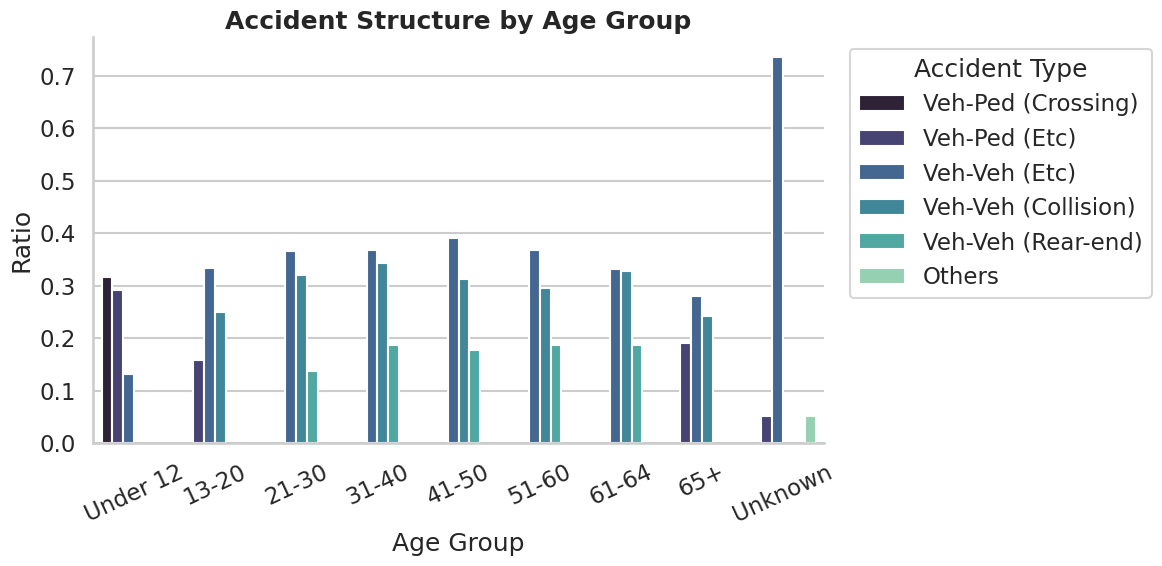

In [73]:
plot_df = top_acc_by_age.copy()

plot_df["age_en"] = plot_df["age_group"].map(age_map)

acc_map = {
    "차대차 - 기타": "Veh-Veh (Etc)",
    "차대차 - 충돌": "Veh-Veh (Collision)",
    "차대차 - 추돌": "Veh-Veh (Rear-end)",
    "차대사람 - 횡단중": "Veh-Ped (Crossing)",
    "차대사람 - 기타": "Veh-Ped (Etc)",
    "차대사람 - 보도통행중": "Veh-Ped (Sidewalk)"
}

plot_df["acc_en"] = plot_df["acc_type"].map(acc_map).fillna("Others")

sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_df,
    x="age_en",
    y="ratio",
    hue="acc_en",
    palette="mako"
)

plt.title("Accident Structure by Age Group", weight="bold")
plt.xlabel("Age Group")
plt.ylabel("Ratio")
plt.xticks(rotation=25)
plt.legend(title="Accident Type", bbox_to_anchor=(1.02, 1))

sns.despine()
plt.tight_layout()
plt.savefig(IMG_DIR / "age_accident_structure.png", dpi=200, bbox_inches="tight")
plt.show()

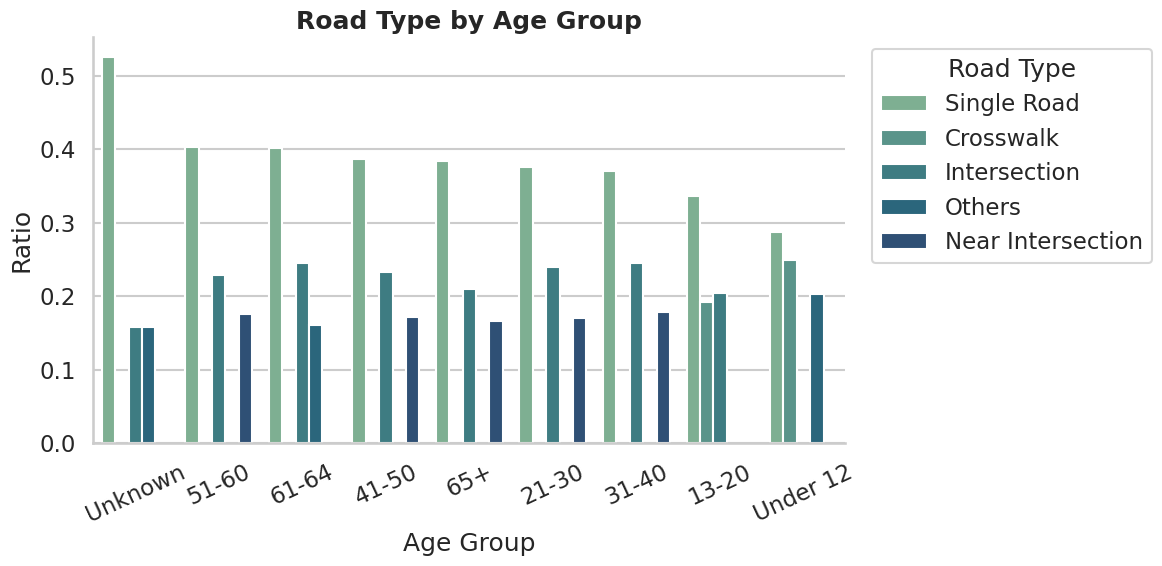

In [75]:
plot_df = age_road.copy()
plot_df = plot_df.sort_values("ratio", ascending=False).groupby("age_group").head(3)

plot_df["age_en"] = plot_df["age_group"].map(age_map)

road_map = {
    "단일로 - 기타": "Single Road",
    "교차로 - 교차로안": "Intersection",
    "교차로 - 교차로횡단보도내": "Crosswalk",
    "교차로 - 교차로부근": "Near Intersection"
}

plot_df["road_en"] = plot_df["road_type"].map(road_map).fillna("Others")

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_df,
    x="age_en",
    y="ratio",
    hue="road_en",
    palette="crest"
)

plt.title("Road Type by Age Group", weight="bold")
plt.xlabel("Age Group")
plt.ylabel("Ratio")
plt.xticks(rotation=25)
plt.legend(title="Road Type", bbox_to_anchor=(1.02, 1))

sns.despine()
plt.tight_layout()
plt.savefig(IMG_DIR / "age_road_structure.png", dpi=200, bbox_inches="tight")
plt.show()

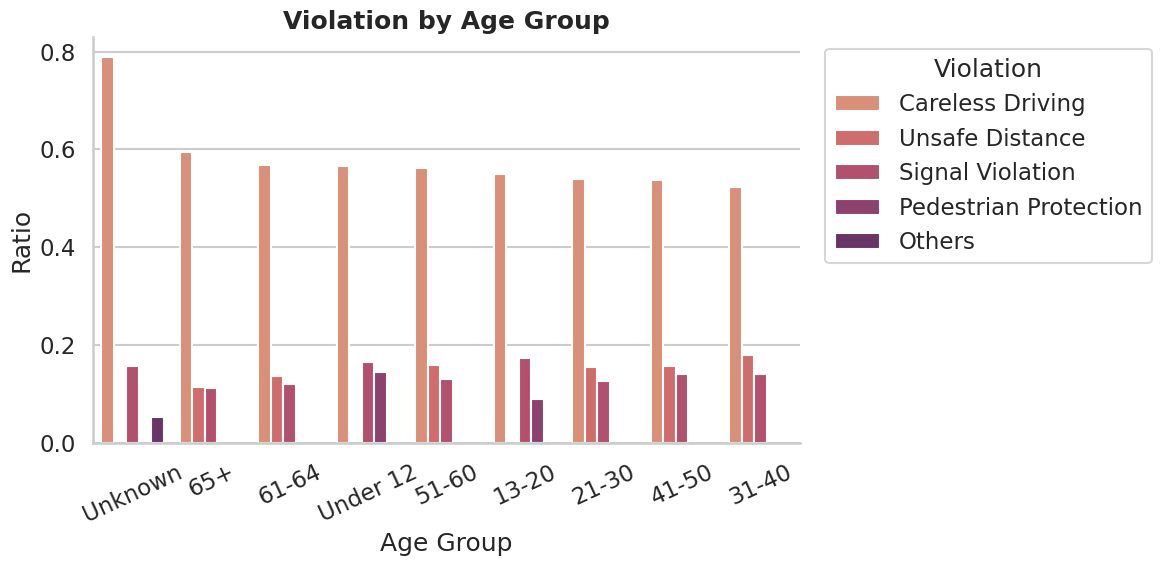

In [76]:
plot_df = age_violation.copy()
plot_df = plot_df.sort_values("ratio", ascending=False).groupby("age_group").head(3)

plot_df["age_en"] = plot_df["age_group"].map(age_map)

vio_map = {
    "안전운전불이행": "Careless Driving",
    "신호위반": "Signal Violation",
    "보행자보호의무위반": "Pedestrian Protection",
    "안전거리미확보": "Unsafe Distance"
}

plot_df["vio_en"] = plot_df["violation"].map(vio_map).fillna("Others")

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_df,
    x="age_en",
    y="ratio",
    hue="vio_en",
    palette="flare"
)

plt.title("Violation by Age Group", weight="bold")
plt.xlabel("Age Group")
plt.ylabel("Ratio")
plt.xticks(rotation=25)
plt.legend(title="Violation", bbox_to_anchor=(1.02, 1))

sns.despine()
plt.tight_layout()
plt.savefig(IMG_DIR / "age_violation_structure.png", dpi=200, bbox_inches="tight")
plt.show()